# Behavioral Feature Engineering

The previous Random Forest experiments showed that improving the representation of existing features, particularly treating MCC as categorical, improved fraud detection performance.

This experiment investigates whether adding behavioral features describing recent transaction activity and transaction timing provides additional predictive information.

The model architecture is kept unchanged so that any difference in performance can be attributed to the extended feature set.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
)

from finsight.database import (
    connect_to_database,
    test_database_connection,
)

from finsight.fraud_data import (
    BASE_FEATURES,
    BEHAVIORAL_FEATURES,
    download_train_data,
    download_validation_data,
)

from finsight.validation import (
    check_missing_values
)

from finsight.fraud_preprocessing  import (
    encode_categorical_features,
    handle_behavioral_missing_values,
    handle_missing_values,
)

In [2]:
engine = connect_to_database()
test_database_connection(engine)

Connected!


## Extended Feature Set

The original feature set is extended with behavioral features describing recent transaction activity and the time elapsed since previous transactions.

The original features are preserved separately to maintain reproducibility of the previous experiments.

In [3]:
extended_features = BASE_FEATURES + BEHAVIORAL_FEATURES

In [4]:
X_train, y_train = download_train_data(engine, features=extended_features)
X_val, y_val = download_validation_data(engine, features=extended_features)

In [5]:
X_train.shape

(310343, 17)

In [6]:
X_val.shape

(934599, 17)

## Data Validation

Before preprocessing, the extended dataset is inspected to verify feature types and identify missing values introduced by the new behavioral features.

In [7]:
X_train.dtypes

amount                             float64
mcc_key                              int64
use_chip                               str
merchant_id                          int64
transaction_hour                   float64
day_of_week                        float64
is_weekend                           int64
user_previous_transaction_count      int64
user_previous_avg_amount           float64
amount_vs_user_avg                 float64
card_previous_transaction_count      int64
card_previous_avg_amount           float64
amount_vs_card_avg                 float64
user_transactions_last_24h           int64
user_amount_last_24h               float64
hours_since_user_transaction       float64
hours_since_card_transaction       float64
dtype: object

In [8]:
check_missing_values(X_train)

amount                                 0
mcc_key                                0
use_chip                               0
merchant_id                            0
transaction_hour                       0
day_of_week                            0
is_weekend                             0
user_previous_transaction_count        0
user_previous_avg_amount              30
amount_vs_user_avg                    30
card_previous_transaction_count        0
card_previous_avg_amount              93
amount_vs_card_avg                    93
user_transactions_last_24h             0
user_amount_last_24h               15977
hours_since_user_transaction          30
hours_since_card_transaction          93
dtype: int64

In [9]:
check_missing_values(X_val)

amount                                 0
mcc_key                                0
use_chip                               0
merchant_id                            0
transaction_hour                       0
day_of_week                            0
is_weekend                             0
user_previous_transaction_count        0
user_previous_avg_amount               0
amount_vs_user_avg                     0
card_previous_transaction_count        0
card_previous_avg_amount              45
amount_vs_card_avg                    45
user_transactions_last_24h             0
user_amount_last_24h               47256
hours_since_user_transaction           0
hours_since_card_transaction          45
dtype: int64

### Missing Value Interpretation

Missing values in the behavioral features have different meanings and should therefore not be handled uniformly.

- Missing `user_amount_last_24h` indicates that no previous transactions occurred within the 24-hour window, so the value can be interpreted as zero.
- Missing `hours_since_user_transaction` indicates that no previous transaction exists for the user.
- Missing `hours_since_card_transaction` indicates that no previous transaction exists for the card.

For the time-based features, additional binary indicators will preserve information about whether transaction history exists before the remaining missing values are imputed.

## Data Preprocessing

The extended feature set requires several preprocessing steps before model training.

First, missing values introduced by the behavioral features are handled according to their meaning. Missing 24-hour transaction amounts are interpreted as zero, while additional binary indicators are created to preserve information about whether previous user or card transaction history exists.

Next, categorical features are prepared for modeling. `mcc_key` is treated as categorical rather than numerical, following the improvement observed in the previous Random Forest experiment. Categorical variables are then one-hot encoded using the training data.

Finally, any remaining missing numerical values are imputed using medians calculated from the training set to avoid information leakage.

In [10]:
X_train_mcc = X_train.copy()
X_val_mcc = X_val.copy()

X_train_mcc["mcc_key"] = X_train_mcc["mcc_key"].astype(str)
X_val_mcc["mcc_key"] = X_val_mcc["mcc_key"].astype(str)

In [11]:
final_train, final_val = encode_categorical_features(X_train_mcc, X_val_mcc)

In [12]:
final_train, final_val = handle_behavioral_missing_values(final_train, final_val)

In [13]:
final_train, final_val = handle_missing_values(final_train, final_val)

In [14]:
check_missing_values(final_train)[check_missing_values(final_train)>0]

Series([], dtype: int64)

In [15]:
check_missing_values(final_val)[check_missing_values(final_val)>0]

Series([], dtype: int64)

## Random Forest with Behavioral Features

To evaluate whether the newly engineered behavioral features provide additional predictive information, a Random Forest model is trained using the extended feature set.

The model configuration is kept consistent with the previous best-performing Random Forest experiment, where `mcc_key` was treated as a categorical feature. This allows the effect of the behavioral features to be evaluated independently of changes to the model itself.

Performance is evaluated on the unchanged time-based validation set using recall, precision and F1-score, enabling a direct comparison with the previous model.

In [16]:
rf_behavioral= RandomForestClassifier(random_state=42)
rf_behavioral.fit(final_train, y_train)
print("Training set score: {:.4f}".format(rf_behavioral.score(final_train, y_train)))
print("Validation set score: {:.4f}".format(rf_behavioral.score(final_val, y_val)))

Training set score: 1.0000
Validation set score: 0.9976


In [17]:
y_pred_behavioral = rf_behavioral.predict(final_val)

In [18]:
recall_behavioral = recall_score(y_val, y_pred_behavioral)
precision_behavioral = precision_score(y_val, y_pred_behavioral)
f1_behavioral = f1_score(y_val, y_pred_behavioral)
print("Recall: {:.4f}".format(recall_behavioral))
print("Precision: {:.4f}".format(precision_behavioral))
print("F1: {:.4f}".format(f1_behavioral))

Recall: 0.0399
Precision: 0.0889
F1: 0.0551


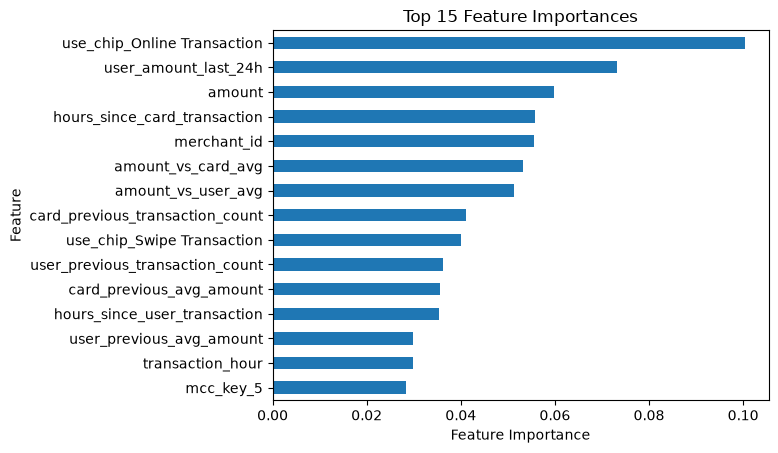

In [26]:
def plot_feature_importances(model, top_n=15):
    importances = pd.Series(
        model.feature_importances_,
        index=final_train.columns
    ).sort_values(ascending=False).head(top_n)

    importances.sort_values().plot.barh()

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Feature Importances")
    plt.show()

plot_feature_importances(rf_behavioral)

### Behavioral Feature Experiment Results

Adding the behavioral features did not improve fraud detection performance.

Compared with the previous Random Forest using categorical MCC, recall decreased from 0.0559 to 0.0417, precision from 0.1117 to 0.0993, and F1-score from 0.0745 to 0.0588.

Despite the decline in validation performance, several behavioral features received relatively high feature importance. `user_amount_last_24h` became one of the most important features in the model, while `hours_since_card_transaction` and `hours_since_user_transaction` also appeared among the top features.

This indicates that the Random Forest used the newly engineered behavioral information when constructing its trees. However, their high feature importance did not translate into better fraud detection on the time-based validation set.

The experiment demonstrates that feature importance alone should not be interpreted as evidence that a feature improves model generalization. Since the extended feature set reduced recall, precision and F1-score, further expansion with similar behavioral features is not pursued.